In [6]:
!pip install tensorflow==2.10.1 scikit-learn matplotlib numpy==1.26.4 pandas

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.6
    Uninstalling numpy-1.21.6:
      Successfully uninstalled numpy-1.21.6


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import sklearn
import shutil
import glob
import os
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Input, Rescaling, Dense, Flatten, Activation, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [2]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory("./data/train", validation_split=0.2, seed=42, subset="training", shuffle=True, label_mode="categorical", batch_size=32, image_size=(224, 224), interpolation="nearest")

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


In [4]:
valid_ds = tf.keras.utils.image_dataset_from_directory("./data/train", validation_split=0.2, seed=42, subset="validation", shuffle=True, label_mode="categorical", batch_size=32, image_size=(224, 224), interpolation="nearest")

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory("./data/test", shuffle=False, label_mode="categorical", batch_size=32, image_size=(224, 224), interpolation="nearest")

Found 1600 files belonging to 4 classes.


In [6]:
train_ds

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [7]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

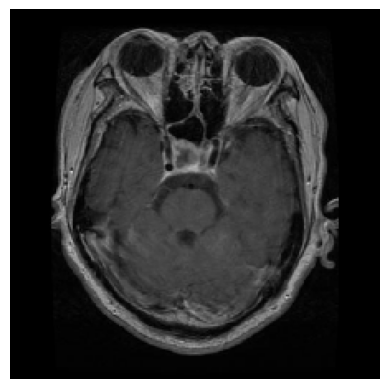

In [8]:
for images, labels in train_ds.take(2):
    plt.imshow(images[0].numpy().reshape(224, 224, 3))
    plt.axis("off")

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [10]:
classes = ["glioma", "meningioma", "notumor", "pituitary"]

In [34]:
model = tf.keras.Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(data_augmentation)
model.add(Rescaling(1./255))
model.add(Conv2D(16, (3, 3), padding='same', name='conv1'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Conv2D(16, (3, 3), padding='same', name='conv2'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2), name='pool1'))


model.add(Conv2D(32, (3, 3), padding='same', name='conv3'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Conv2D(32, (3, 3), padding='same', name='conv4'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Conv2D(32, (3, 3), padding='same', name='conv5'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2), name='pool2'))

model.add(Conv2D(64, (3, 3), padding='same', name='conv6'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Conv2D(64, (3, 3), padding='same', name='conv7'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Conv2D(64, (3, 3), padding='same', name='conv8'))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPool2D(pool_size=(2, 2), name='pool3'))

model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu', name='fc1'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu', name='fc2'))
model.add(Dropout(0.4))
model.add(Dense(32, activation='relu', name='fc3'))
model.add(Dense(4, activation='softmax', name='fc4'))

In [35]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv1 (Conv2D)              (None, 224, 224, 16)      448       
                                                                 
 batch_normalization_16 (Bat  (None, 224, 224, 16)     64        
 chNormalization)                                                
                                                                 
 activation_16 (Activation)  (None, 224, 224, 16)      0         
                                                                 
 conv2 (Conv2D)              (None, 224, 224, 16)      2320      
                                                      

In [36]:
reduceLR = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=4)
earlyStop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint('my_best_model.keras', monitor="val_accuracy", verbose=1, save_best_only=True)

In [37]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=categorical_crossentropy, metrics=['accuracy'])

In [38]:
model.fit(train_ds, validation_data=valid_ds, epochs=200, callbacks=[checkpoint, reduceLR, earlyStop])

Epoch 1/200
140/140 [==============================] - ETA: 0s - loss: 1.1144 - accuracy: 0.4846
Epoch 1: val_accuracy improved from -inf to 0.23214, saving model to my_best_model.keras
140/140 [==============================] - 47s 320ms/step - loss: 1.1144 - accuracy: 0.4846 - val_loss: 2.9881 - val_accuracy: 0.2321 - lr: 0.0010
Epoch 2/200
140/140 [==============================] - ETA: 0s - loss: 0.9645 - accuracy: 0.5750
Epoch 2: val_accuracy improved from 0.23214 to 0.23482, saving model to my_best_model.keras
140/140 [==============================] - 45s 320ms/step - loss: 0.9645 - accuracy: 0.5750 - val_loss: 3.0226 - val_accuracy: 0.2348 - lr: 0.0010
Epoch 3/200
140/140 [==============================] - ETA: 0s - loss: 0.8942 - accuracy: 0.5998
Epoch 3: val_accuracy improved from 0.23482 to 0.42768, saving model to my_best_model.keras
140/140 [==============================] - 45s 321ms/step - loss: 0.8942 - accuracy: 0.5998 - val_loss: 1.5849 - val_accuracy: 0.4277 - lr: 0.

In [39]:
model.evaluate(test_ds)

50/50 [==============================] - 3s 47ms/step - loss: 0.5167 - accuracy: 0.8506


[0.5167465806007385, 0.8506249785423279]

50/50 [==============================] - 2s 49ms/step
              precision    recall  f1-score   support

           0       0.92      0.70      0.80       400
           1       0.75      0.78      0.76       400
           2       0.83      0.99      0.91       400
           3       0.92      0.93      0.93       400

    accuracy                           0.85      1600
   macro avg       0.86      0.85      0.85      1600
weighted avg       0.86      0.85      0.85      1600



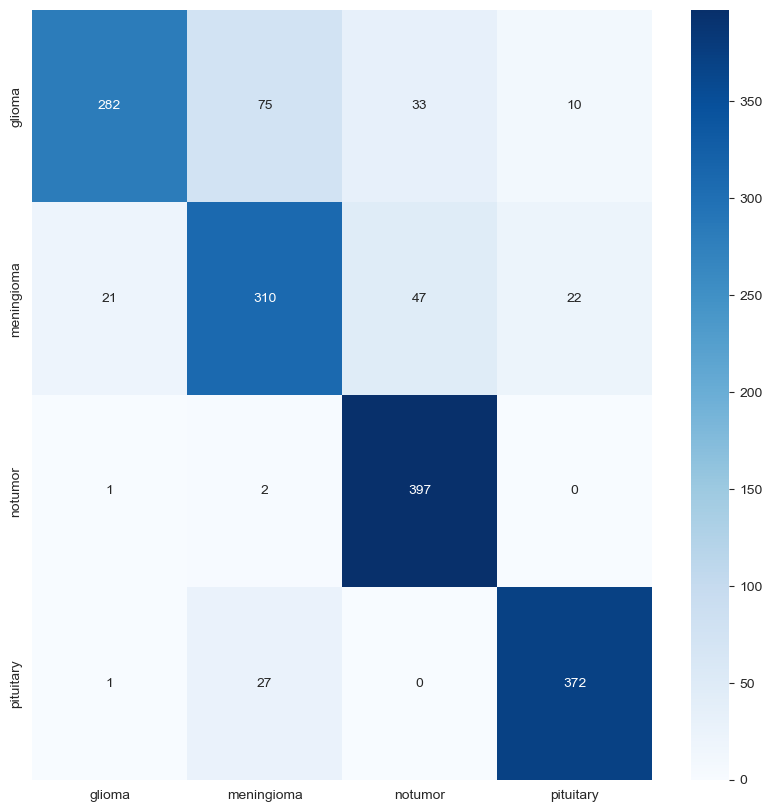

In [47]:
test_preds = model.predict(test_ds)
test_preds = np.argmax(test_preds, axis=1)
test_true = []
for images, labels in test_ds:
    test_true.extend(tf.argmax(labels, axis=1).numpy())

test_true = np.array(test_true)

cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", xticklabels=classes, yticklabels=classes)
print(classification_report(test_true, test_preds))

In [48]:
mobileNet = tf.keras.applications.mobilenet.MobileNet(include_top=False, input_shape=(224, 224, 3), pooling='max', weights='imagenet')

In [49]:
mobileNet.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

In [50]:
mobileNet.trainable = False
x = mobileNet.layers[-5].output
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(4, activation='softmax')(x)
MobileNet_model = tf.keras.Model(mobileNet.input, x)
MobileNet_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                                      

In [51]:
test_ds.map(lambda x, y : (preprocess_input(tf.cast(x, tf.float32)), y))

<MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [52]:
mobileNet_early_stoping = EarlyStopping(monitor='val_accuracy', patience=8, verbose=0, mode='max', restore_best_weights=True)
mobileNet_checkpoint = ModelCheckpoint("best_model_mobileNet.keras", monitor="val_accuracy", save_best_only=True, verbose=1, mode="max")

In [53]:
MobileNet_model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.Adam(0.001), metrics=['accuracy'])

In [54]:
history = MobileNet_model.fit(train_ds, validation_data=valid_ds, epochs=30, verbose=2, callbacks=[mobileNet_early_stoping, mobileNet_checkpoint])

Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.88125, saving model to best_model_mobileNet.keras
140/140 - 9s - loss: 0.7416 - accuracy: 0.7290 - val_loss: 0.3572 - val_accuracy: 0.8813 - 9s/epoch - 64ms/step
Epoch 2/30

Epoch 2: val_accuracy improved from 0.88125 to 0.91339, saving model to best_model_mobileNet.keras
140/140 - 7s - loss: 0.4430 - accuracy: 0.8391 - val_loss: 0.2339 - val_accuracy: 0.9134 - 7s/epoch - 50ms/step
Epoch 3/30

Epoch 3: val_accuracy improved from 0.91339 to 0.92768, saving model to best_model_mobileNet.keras
140/140 - 7s - loss: 0.3177 - accuracy: 0.8873 - val_loss: 0.1905 - val_accuracy: 0.9277 - 7s/epoch - 49ms/step
Epoch 4/30

Epoch 4: val_accuracy improved from 0.92768 to 0.94107, saving model to best_model_mobileNet.keras
140/140 - 7s - loss: 0.2447 - accuracy: 0.9123 - val_loss: 0.1623 - val_accuracy: 0.9411 - 7s/epoch - 49ms/step
Epoch 5/30

Epoch 5: val_accuracy improved from 0.94107 to 0.94732, saving model to best_model_mobileNet.keras


1/1 [==============================] - 0s 19ms/step


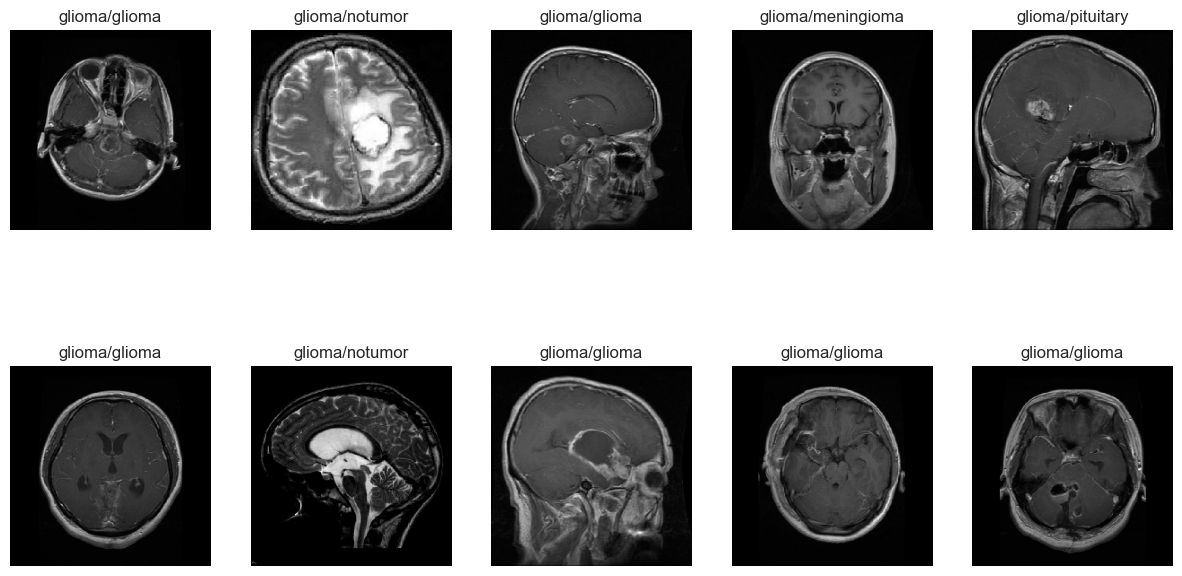

In [55]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15,8))
ax = ax.flatten()
for images, labels in test_ds.take(2):
    preds = MobileNet_model.predict(images)
    for i in range(10):
        ax[i].imshow(images[i])
        ax[i].set_title(classes[labels[i].numpy().argmax()] +'/'+ classes[preds[i].argmax(axis=-1)])
        ax[i].axis("off")

In [56]:
MobileNet_model.evaluate(test_ds)

50/50 [==============================] - 2s 36ms/step - loss: 0.5585 - accuracy: 0.9056


[0.5585374236106873, 0.9056249856948853]

In [57]:
test_preds = MobileNet_model.predict(test_ds).argmax(axis=-1)
test_preds.shape

50/50 [==============================] - 2s 33ms/step


(1600,)

              precision    recall  f1-score   support

           0       0.95      0.73      0.82       400
           1       0.85      0.91      0.88       400
           2       0.88      1.00      0.94       400
           3       0.95      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600



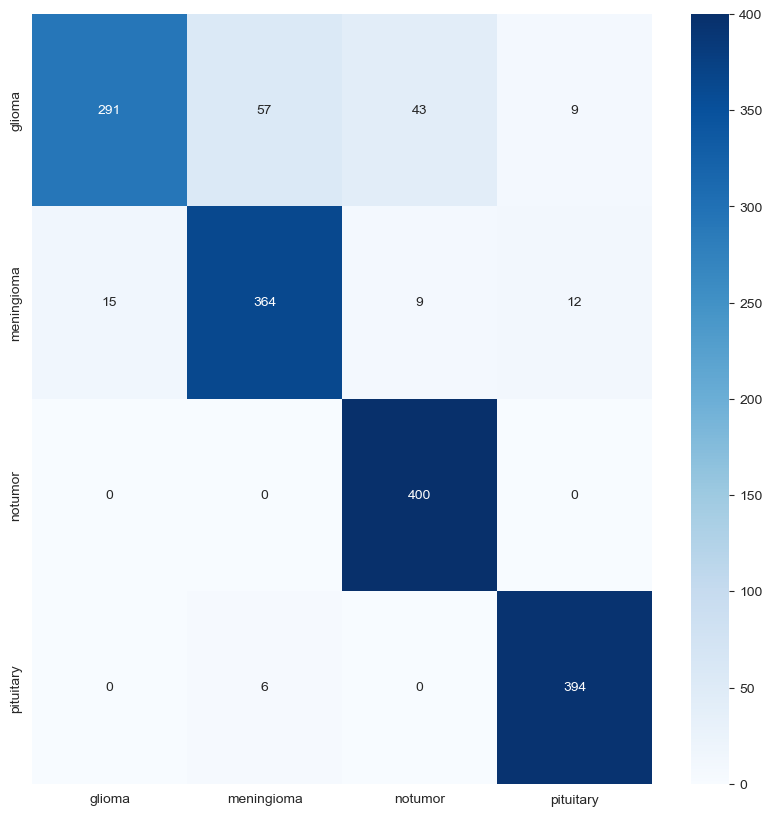

In [60]:
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", xticklabels=classes, yticklabels=classes)
print(classification_report(test_true, test_preds))

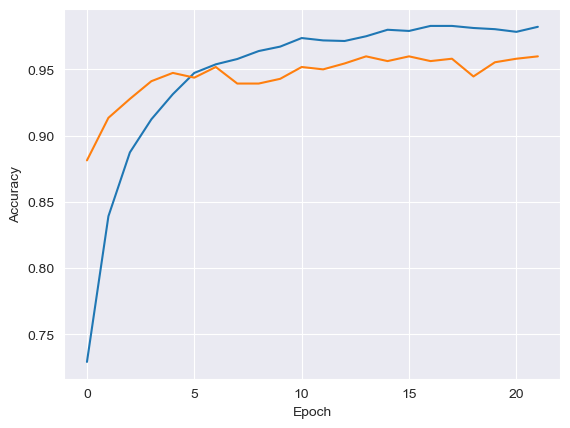

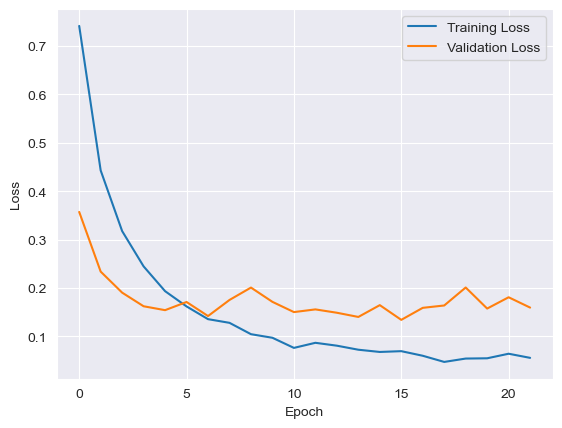

In [61]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()